# Box-Jenkins Zeitreihenanalyse: Gold (GC=F)
> **Projekt:** Asset Forecasting — DAX, Gold & Bitcoin  
> **Kurs:** Vertiefung Business Analytics · THWS · SoSe 2026  
> **Prof.:** Dr. Christian Menden  
> **Autor:** Antonio Sicaja  
> **Asset:** Gold (Ticker: `GC=F`) · täglich · 2016–2026

---

## Methodik — Box-Jenkins in 4 Schritten

1. **Identifikation** — Stationaritätsprüfung (ADF, KPSS), ACF/PACF
2. **Schätzung** — Gittersuche über ARIMA(p,d,q)
3. **Diagnostik** — Residualanalyse (Ljung-Box, Jarque-Bera)
4. **Prognose** — 10-Perioden-Forecast mit 95%-Konfidenzintervall

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot-Stil
plt.style.use('seaborn-v0_8-darkgrid')
GOLD  = '#FFD700'
BLUE  = '#2196F3'
RED   = '#F44336'
GREEN = '#4CAF50'

print('Setup abgeschlossen ✓')

Setup abgeschlossen ✓


---
## 1. Daten laden & aufbereiten

In [2]:
import os

# Rohdaten laden
DATA_PATH = '../data/raw/goldpreis_2016_2026.csv'

df = pd.read_csv(DATA_PATH, skiprows=1)
df.columns = ['Date', 'Close']
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
close = df['Close'].dropna()

# Log-Returns
log_ret = np.log(close).diff().dropna()

print(f'Zeitraum    : {close.index[0].date()} → {close.index[-1].date()}')
print(f'Handelstage : {len(close)}')
print(f'Preis Start : {close.iloc[0]:.2f} USD/oz')
print(f'Preis Ende  : {close.iloc[-1]:.2f} USD/oz')
print(f'Gesamtrendite: {(close.iloc[-1]/close.iloc[0] - 1)*100:.1f}%')

Zeitraum    : 2016-01-04 → 2026-05-01
Handelstage : 2596
Preis Start : 1075.10 USD/oz
Preis Ende  : 4629.90 USD/oz
Gesamtrendite: 330.6%


In [3]:
# Deskriptive Statistiken
desc = pd.DataFrame({
    'Preis (USD/oz)': close.describe(),
    'Log-Returns': log_ret.describe()
})
print(desc.round(6))
print(f'\nLog-Returns:')
print(f'  Schiefe  : {log_ret.skew():.4f}')
print(f'  Kurtosis : {log_ret.kurtosis():.4f}  (Normal = 0, Leptokurtisch > 0)')

       Preis (USD/oz)  Log-Returns
count     2596.000000  2595.000000
mean      1928.571647     0.000563
std        843.200872     0.010428
min       1073.900024    -0.120657
25%       1306.024994    -0.004171
50%       1773.599976     0.000669
75%       1988.724976     0.005943
max       5318.399902     0.059054

Log-Returns:
  Schiefe  : -0.7997
  Kurtosis : 10.6055  (Normal = 0, Leptokurtisch > 0)


---
## 2. Explorative Analyse (EDA)

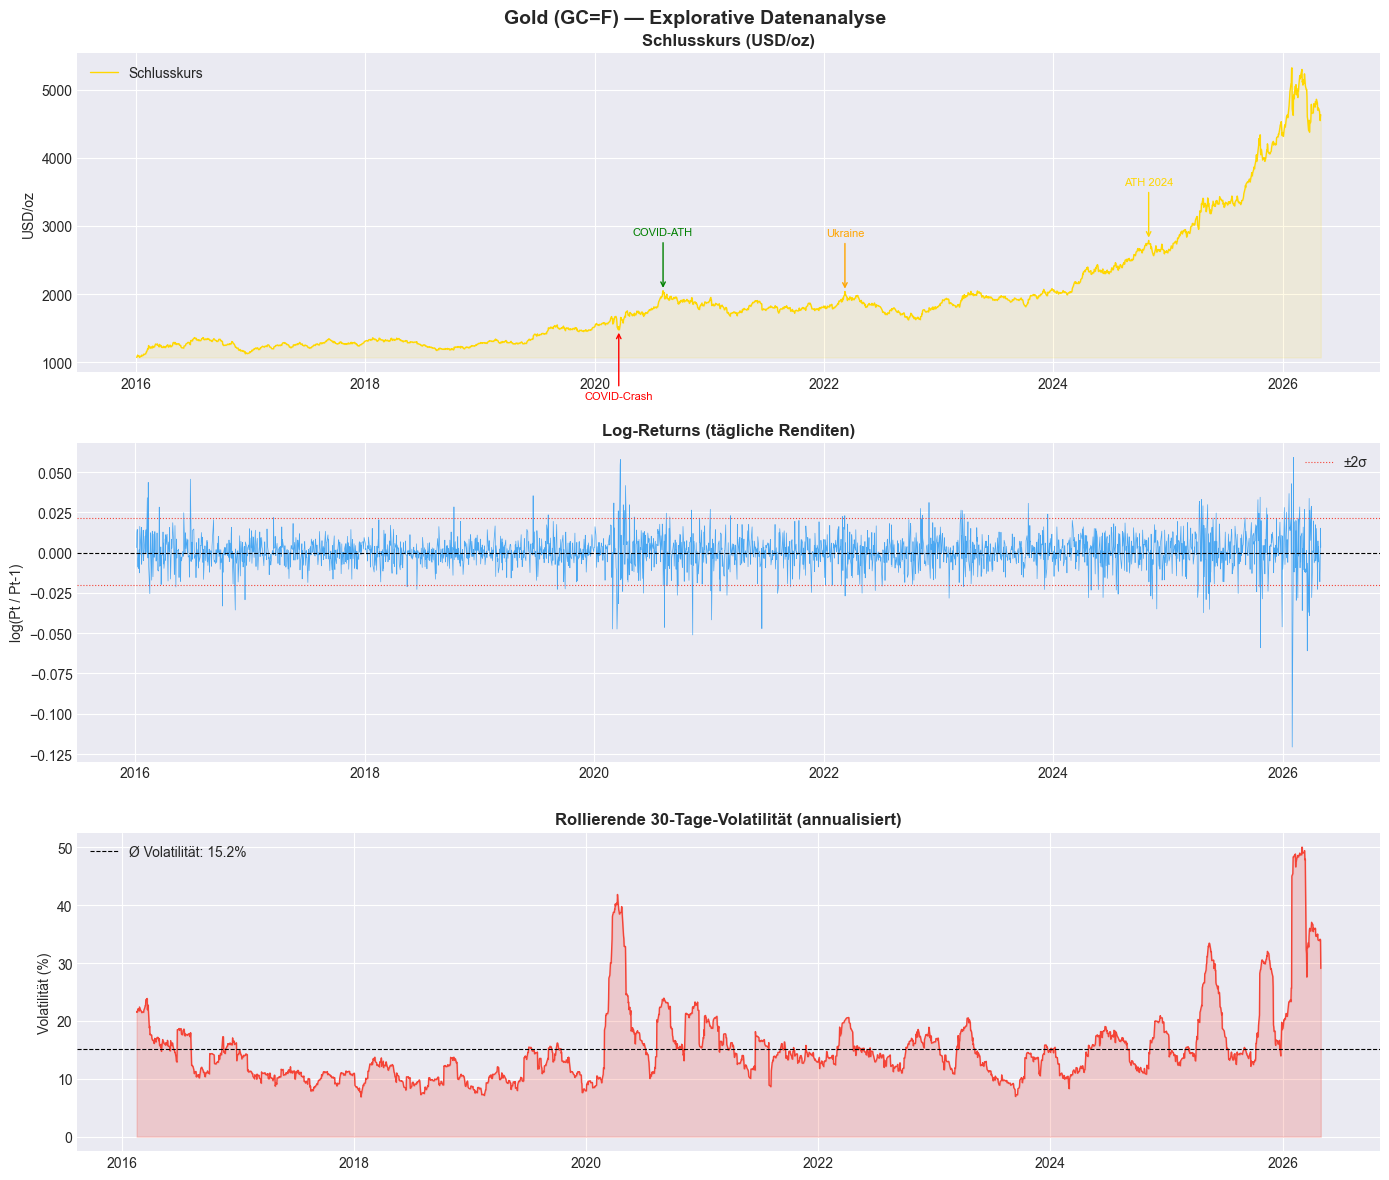

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Gold (GC=F) — Explorative Datenanalyse', fontsize=14, fontweight='bold')

# Preisverlauf
axes[0].plot(close, color=GOLD, linewidth=1.0, label='Schlusskurs')
axes[0].fill_between(close.index, close, close.min(), alpha=0.1, color=GOLD)
axes[0].set_title('Schlusskurs (USD/oz)', fontweight='bold')
axes[0].set_ylabel('USD/oz')
events = [
    ('2020-03-18', 'COVID-Crash', 'red', -50),
    ('2020-08-06', 'COVID-ATH', 'green', 40),
    ('2022-03-08', 'Ukraine', 'orange', 40),
    ('2024-10-30', 'ATH 2024', 'gold', 40),
]
for date, label, color, yoff in events:
    idx = close.index.get_indexer([date], method='nearest')[0]
    axes[0].annotate(label, xy=(close.index[idx], close.iloc[idx]),
                     xytext=(0, yoff), textcoords='offset points',
                     fontsize=8, color=color, ha='center',
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.0))
axes[0].legend()

# Log-Returns
axes[1].plot(log_ret, color=BLUE, linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(log_ret.mean() + 2*log_ret.std(), color=RED, linewidth=0.8,
                linestyle=':', label='±2σ')
axes[1].axhline(log_ret.mean() - 2*log_ret.std(), color=RED, linewidth=0.8, linestyle=':')
axes[1].set_title('Log-Returns (tägliche Renditen)', fontweight='bold')
axes[1].set_ylabel('log(Pt / Pt-1)')
axes[1].legend()

# Rollierende Volatilität
rolling_vol = log_ret.rolling(30).std() * np.sqrt(252) * 100
axes[2].plot(rolling_vol, color=RED, linewidth=1.0)
axes[2].fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color=RED)
axes[2].axhline(rolling_vol.mean(), color='black', linewidth=0.8, linestyle='--',
                label=f'Ø Volatilität: {rolling_vol.mean():.1f}%')
axes[2].set_title('Rollierende 30-Tage-Volatilität (annualisiert)', fontweight='bold')
axes[2].set_ylabel('Volatilität (%)')
axes[2].legend()

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/gold_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Stationaritätsprüfung (Box-Jenkins Schritt 1)

In [5]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    print(f'ADF-Test: {name}')
    print(f'  Teststatistik : {stat:.4f}')
    print(f'  p-Wert        : {pval:.4f}  → {"✅ Stationär" if pval < 0.05 else "❌ Nicht stationär"} (α=5%)')
    print(f'  Kritische Werte: 1%={crit["1%"]:.3f}, 5%={crit["5%"]:.3f}')
    print()

def kpss_test(series, name=''):
    stat, pval, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS-Test: {name}')
    print(f'  Teststatistik : {stat:.4f}')
    print(f'  p-Wert        : {pval:.4f}  → {"❌ Nicht stationär" if pval < 0.05 else "✅ Stationär"} (α=5%)')
    print()

print('='*55)
print('STATIONARITÄTSPRÜFUNG — NIVEAUPREISE')
print('='*55)
adf_test(close, 'Gold Schlusskurs')
kpss_test(close, 'Gold Schlusskurs')

print('='*55)
print('STATIONARITÄTSPRÜFUNG — LOG-RETURNS')
print('='*55)
adf_test(log_ret, 'Gold Log-Returns')
kpss_test(log_ret, 'Gold Log-Returns')

print('→ Fazit: Niveaupreise sind I(1) → d=1 im ARIMA-Modell.')

STATIONARITÄTSPRÜFUNG — NIVEAUPREISE
ADF-Test: Gold Schlusskurs
  Teststatistik : 2.3845
  p-Wert        : 0.9990  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

KPSS-Test: Gold Schlusskurs
  Teststatistik : 5.7689
  p-Wert        : 0.0100  → ❌ Nicht stationär (α=5%)

STATIONARITÄTSPRÜFUNG — LOG-RETURNS
ADF-Test: Gold Log-Returns
  Teststatistik : -20.9622
  p-Wert        : 0.0000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

KPSS-Test: Gold Log-Returns
  Teststatistik : 0.2976
  p-Wert        : 0.1000  → ✅ Stationär (α=5%)

→ Fazit: Niveaupreise sind I(1) → d=1 im ARIMA-Modell.


/var/folders/lg/pl_rdj692ydcjhcfjzd9_9gm0000gn/T/ipykernel_12989/2601109857.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/lg/pl_rdj692ydcjhcfjzd9_9gm0000gn/T/ipykernel_12989/2601109857.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')


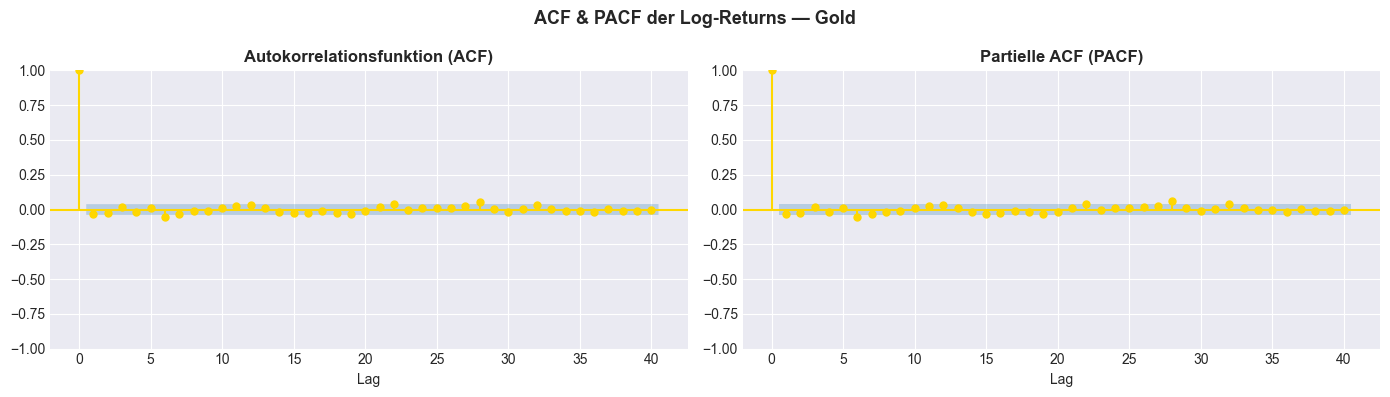

Interpretation:
  ACF : Kein signifikanter Peak ab Lag 1 → wenig MA-Struktur
  PACF: Kein signifikanter Peak ab Lag 1 → wenig AR-Struktur
  → Random-Walk-Charakteristik der Goldpreise bestätigt


In [6]:
# ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACF & PACF der Log-Returns — Gold', fontsize=13, fontweight='bold')

plot_acf(log_ret, lags=40, ax=axes[0], color=GOLD, vlines_kwargs={'colors': GOLD})
axes[0].set_title('Autokorrelationsfunktion (ACF)', fontweight='bold')
axes[0].set_xlabel('Lag')

plot_pacf(log_ret, lags=40, ax=axes[1], method='ywm', color=GOLD,
          vlines_kwargs={'colors': GOLD})
axes[1].set_title('Partielle ACF (PACF)', fontweight='bold')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('../reports/gold_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  ACF : Kein signifikanter Peak ab Lag 1 → wenig MA-Struktur')
print('  PACF: Kein signifikanter Peak ab Lag 1 → wenig AR-Struktur')
print('  → Random-Walk-Charakteristik der Goldpreise bestätigt')

---
## 4. Modellidentifikation & Schätzung (Box-Jenkins Schritt 2)

In [7]:
# Train-Test-Split (letzte 60 Handelstage)
TEST_SIZE = 60
train = close.iloc[:-TEST_SIZE]
test  = close.iloc[-TEST_SIZE:]

print(f'Training: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} Tage)')
print(f'Test    : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} Tage)')

Training: 2016-01-04 → 2026-02-04 (2536 Tage)
Test    : 2026-02-05  → 2026-05-01  (60 Tage)


In [8]:
# Gittersuche über ARIMA(p, 1, q)
results = []

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(np.log(train), order=(p, 1, q)).fit()
            fc    = np.exp(model.forecast(TEST_SIZE))
            mae   = np.mean(np.abs(fc.values - test.values))
            rmse  = np.sqrt(np.mean((fc.values - test.values)**2))
            mape  = np.mean(np.abs((fc.values - test.values) / test.values)) * 100
            mase  = mae / np.mean(np.abs(np.diff(train.values)))
            results.append({
                'Modell': f'ARIMA({p},1,{q})',
                'p': p, 'd': 1, 'q': q,
                'AIC': model.aic, 'BIC': model.bic,
                'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'MASE': mase
            })
        except:
            pass

res_df = pd.DataFrame(results).sort_values('AIC')
print('Top 8 Modelle nach AIC:')
print(res_df[['Modell','AIC','BIC','MAE','RMSE','MAPE (%)','MASE']].head(8).round(4).to_string(index=False))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin

Top 8 Modelle nach AIC:
      Modell         AIC         BIC      MAE     RMSE  MAPE (%)    MASE
ARIMA(0,1,2) -16081.5578 -16064.0440 211.4912 244.5065    4.4205 14.9415
ARIMA(2,1,0) -16081.5174 -16064.0035 211.4739 244.4843    4.4201 14.9403
ARIMA(1,1,2) -16081.3245 -16057.9727 212.1786 245.7401    4.4395 14.9901
ARIMA(2,1,1) -16081.0101 -16057.6583 212.0937 245.6115    4.4373 14.9841
ARIMA(0,1,0) -16080.8141 -16074.9762 213.0583 247.2974    4.4631 15.0522
ARIMA(0,1,3) -16080.4367 -16057.0849 211.7790 245.0917    4.4288 14.9619
ARIMA(3,1,0) -16080.2695 -16056.9177 211.8295 245.1953    4.4303 14.9654
ARIMA(0,1,1) -16079.5296 -16067.8537 213.0095 247.2030    4.4618 15.0488


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [9]:
# Bestes Modell
best_row = res_df.iloc[0]
p_best, d_best, q_best = int(best_row['p']), int(best_row['d']), int(best_row['q'])
print(f'✅ Bestes Modell: ARIMA({p_best},{d_best},{q_best})')

best_model = ARIMA(np.log(train), order=(p_best, d_best, q_best)).fit()

# Backtesting
fc_obj  = best_model.get_forecast(steps=TEST_SIZE)
fc_mean = np.exp(fc_obj.predicted_mean)
fc_ci   = np.exp(fc_obj.conf_int(alpha=0.05))
fc_mean.index = test.index
fc_ci.index   = test.index
fc_ci.columns = ['KI_unten', 'KI_oben']

mae  = np.mean(np.abs(fc_mean.values - test.values))
rmse = np.sqrt(np.mean((fc_mean.values - test.values)**2))
mape = np.mean(np.abs((fc_mean.values - test.values) / test.values)) * 100
mase = mae / np.mean(np.abs(np.diff(train.values)))

print(f'\nBacktesting-Metriken (60-Tage Out-of-Sample):')
print(f'  AIC   = {best_model.aic:.4f}')
print(f'  BIC   = {best_model.bic:.4f}')
print(f'  MAE   = {mae:.2f} USD/oz')
print(f'  RMSE  = {rmse:.2f} USD/oz')
print(f'  MAPE  = {mape:.4f}%')
print(f'  MASE  = {mase:.4f}')
print()
print(best_model.summary())

✅ Bestes Modell: ARIMA(0,1,2)

Backtesting-Metriken (60-Tage Out-of-Sample):
  AIC   = -16081.5578
  BIC   = -16064.0440
  MAE   = 211.49 USD/oz
  RMSE  = 244.51 USD/oz
  MAPE  = 4.4205%
  MASE  = 14.9415

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2536
Model:                 ARIMA(0, 1, 2)   Log Likelihood                8043.779
Date:                Sun, 17 May 2026   AIC                         -16081.558
Time:                        15:40:49   BIC                         -16064.044
Sample:                             0   HQIC                        -16075.204
                               - 2536                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin

---
## 5. Residualdiagnostik (Box-Jenkins Schritt 3)

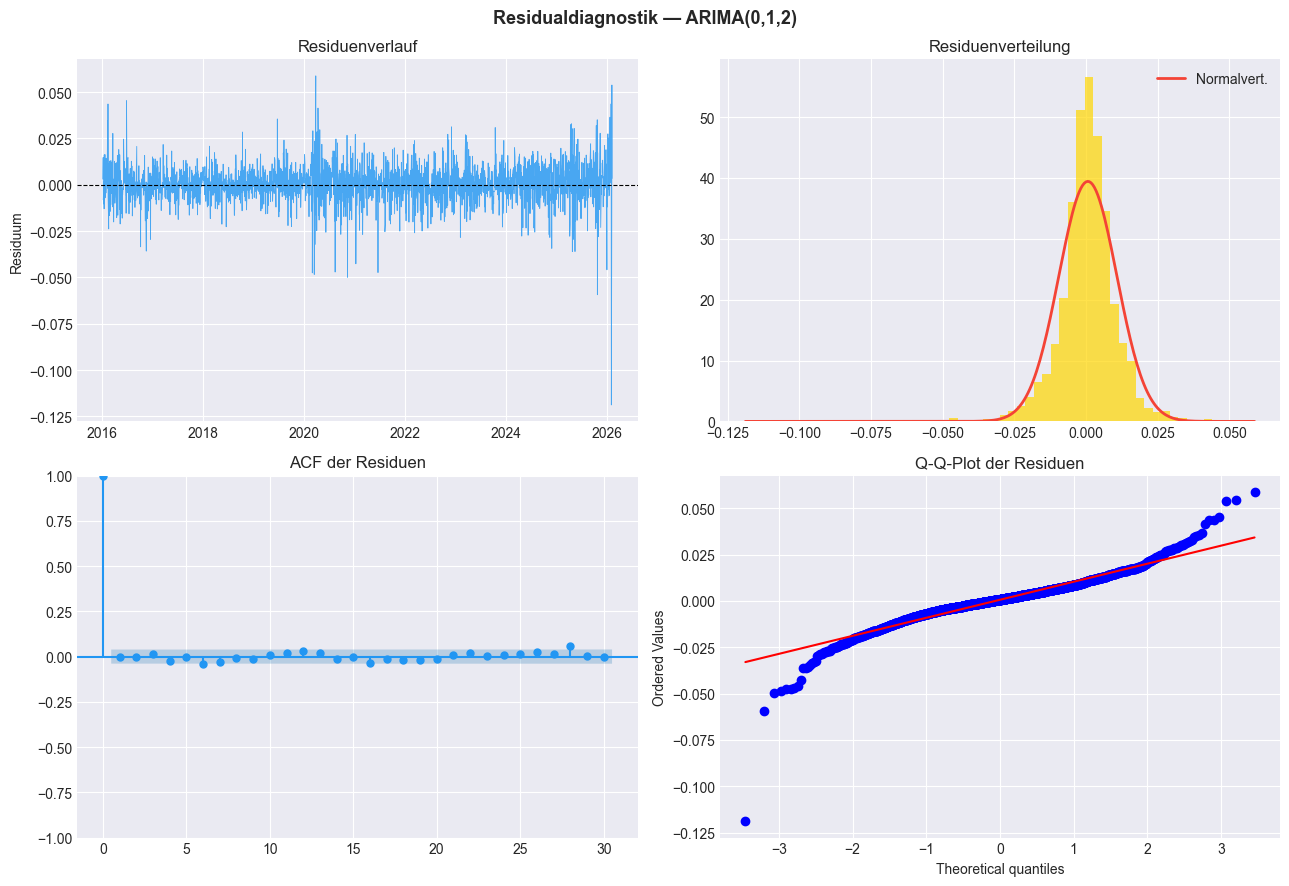

Ljung-Box-Test:
        lb_stat  lb_pvalue
Lag 5    1.8825     0.8651
Lag 10   9.0181     0.5304
Lag 20  19.5607     0.4857

→ p > 0.05: Residuen sind Weißes Rauschen ✅

Jarque-Bera-Test: Statistik=13250.64, p=0.0000
→ Residuen nicht normalverteilt (Leptokurtisch) — typisch für Finanzdaten ⚠️


In [10]:
residuals = best_model.resid.iloc[1:]  # ersten Tag entfernen (Initialisierungsfehler)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Residualdiagnostik — ARIMA({p_best},{d_best},{q_best})',
             fontsize=13, fontweight='bold')

# Residuenverlauf
axes[0, 0].plot(residuals, color=BLUE, linewidth=0.6, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Residuenverlauf')
axes[0, 0].set_ylabel('Residuum')

# Histogramm
axes[0, 1].hist(residuals, bins=60, density=True, color=GOLD, alpha=0.7, edgecolor='none')
x = np.linspace(residuals.min(), residuals.max(), 300)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
                color=RED, linewidth=2, label='Normalvert.')
axes[0, 1].set_title('Residuenverteilung')
axes[0, 1].legend()

# ACF der Residuen
plot_acf(residuals, lags=30, ax=axes[1, 0], color=BLUE,
         vlines_kwargs={'colors': BLUE})
axes[1, 0].set_title('ACF der Residuen')

# Q-Q-Plot
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q-Plot der Residuen')

plt.tight_layout()
plt.savefig('../reports/gold_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box-Test
print('Ljung-Box-Test:')
lb = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
lb.index = [f'Lag {l}' for l in [5, 10, 20]]
print(lb.round(4))
print('\n→ p > 0.05: Residuen sind Weißes Rauschen ✅' if (lb['lb_pvalue'] > 0.05).all() else
      '\n→ p < 0.05: Noch Autokorrelationsstruktur vorhanden ⚠️')

# Jarque-Bera-Test
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f'\nJarque-Bera-Test: Statistik={jb_stat:.2f}, p={jb_p:.4f}')
print('→ ' + ('Residuen normalverteilt ✅' if jb_p > 0.05 else
               'Residuen nicht normalverteilt (Leptokurtisch) — typisch für Finanzdaten ⚠️'))

---
## 6. Prognose (Box-Jenkins Schritt 4)

In [11]:
# Finales Modell auf gesamten Datensatz
final_model = ARIMA(np.log(close), order=(p_best, d_best, q_best)).fit()

# 10-Perioden-Prognose
fc10_obj  = final_model.get_forecast(steps=10)
fc10_mean = np.exp(fc10_obj.predicted_mean)
fc10_ci   = np.exp(fc10_obj.conf_int(alpha=0.05))
fc10_dates = pd.bdate_range(close.index[-1] + pd.Timedelta(days=1), periods=10)
fc10_mean.index = fc10_dates
fc10_ci.index   = fc10_dates
fc10_ci.columns = ['KI_unten (95%)', 'KI_oben (95%)']

forecast_table = pd.DataFrame({
    'Handelstag': range(1, 11),
    'Datum': fc10_dates,
    'Prognose (USD/oz)': fc10_mean.round(2).values,
    'KI untere Grenze': fc10_ci['KI_unten (95%)'].round(2).values,
    'KI obere Grenze':  fc10_ci['KI_oben (95%)'].round(2).values,
    'KI-Breite': (fc10_ci['KI_oben (95%)'] - fc10_ci['KI_unten (95%)']).round(2).values,
})
forecast_table.set_index('Handelstag', inplace=True)

print(f'10-Perioden-Prognose Gold — ARIMA({p_best},{d_best},{q_best}):')
print(forecast_table.to_string())

10-Perioden-Prognose Gold — ARIMA(0,1,2):
                Datum  Prognose (USD/oz)  KI untere Grenze  KI obere Grenze  KI-Breite
Handelstag                                                                            
1          2026-05-04            4627.85           4534.17          4723.47     189.30
2          2026-05-05            4627.46           4497.28          4761.41     264.13
3          2026-05-06            4627.46           4470.51          4789.93     319.43
4          2026-05-07            4627.46           4447.85          4814.33     366.48
5          2026-05-08            4627.46           4427.88          4836.04     408.16
6          2026-05-11            4627.46           4409.85          4855.82     445.97
7          2026-05-12            4627.46           4393.30          4874.12     480.82
8          2026-05-13            4627.46           4377.92          4891.24     513.32
9          2026-05-14            4627.46           4363.50          4907.39     543.89
1

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin

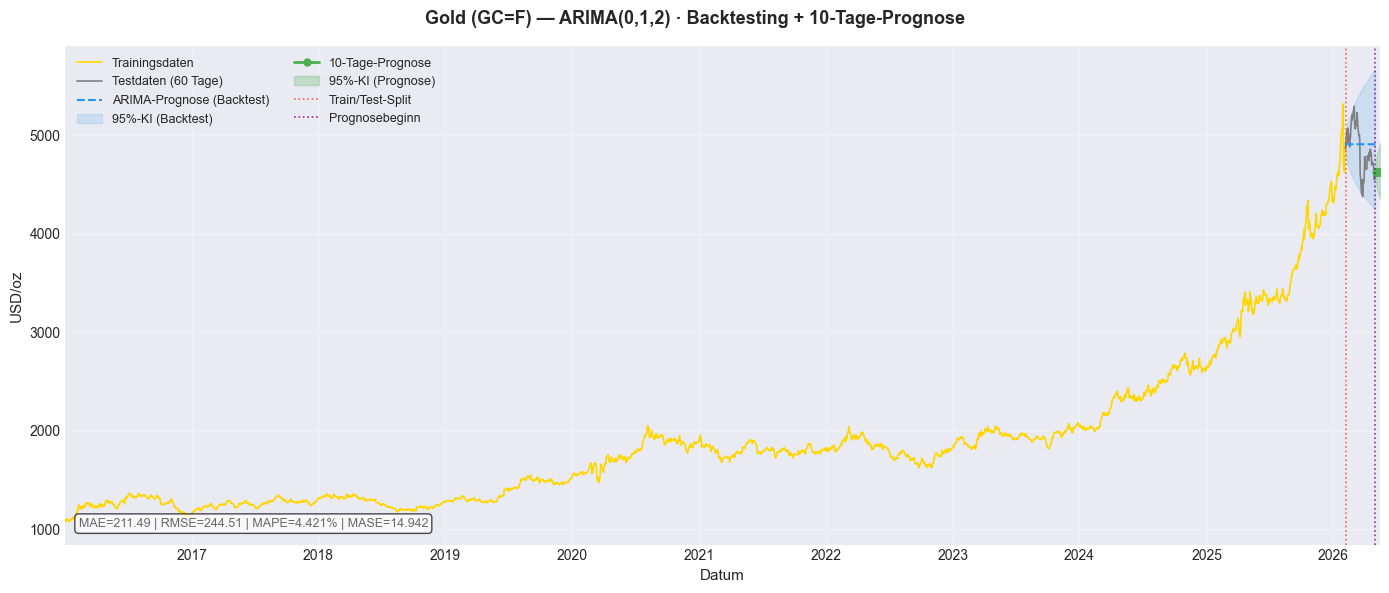

In [12]:
# Visualisierung: Backtesting + 10-Tage-Prognose
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(f'Gold (GC=F) — ARIMA({p_best},{d_best},{q_best}) · Backtesting + 10-Tage-Prognose',
             fontsize=13, fontweight='bold')

show_from = train.index[0]  # ab 2016
ax.plot(train[show_from:], color=GOLD, linewidth=1.2, label='Trainingsdaten')
ax.plot(test, color='gray', linewidth=1.2, label=f'Testdaten ({TEST_SIZE} Tage)')
ax.plot(fc_mean, color=BLUE, linewidth=1.5, linestyle='--', label='ARIMA-Prognose (Backtest)')
ax.fill_between(fc_mean.index, fc_ci['KI_unten'], fc_ci['KI_oben'],
                alpha=0.15, color=BLUE, label='95%-KI (Backtest)')
ax.plot(fc10_mean, color=GREEN, linewidth=2.0, marker='o', markersize=5,
        label='10-Tage-Prognose')
ax.fill_between(fc10_mean.index, fc10_ci['KI_unten (95%)'], fc10_ci['KI_oben (95%)'],
                alpha=0.25, color=GREEN, label='95%-KI (Prognose)')
ax.axvline(test.index[0], color=RED, linewidth=1.2, linestyle=':', alpha=0.8,
           label='Train/Test-Split')
ax.axvline(close.index[-1], color='purple', linewidth=1.2, linestyle=':',
           alpha=0.8, label='Prognosebeginn')
ax.set_xlim(show_from, fc10_mean.index[-1])

metric_text = f'MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.3f}% | MASE={mase:.3f}'
ax.text(0.01, 0.03, metric_text, transform=ax.transAxes, fontsize=9,
        color='dimgray', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_ylabel('USD/oz', fontsize=11)
ax.set_xlabel('Datum', fontsize=11)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gold_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Modellvergleich & Ergebniszusammenfassung

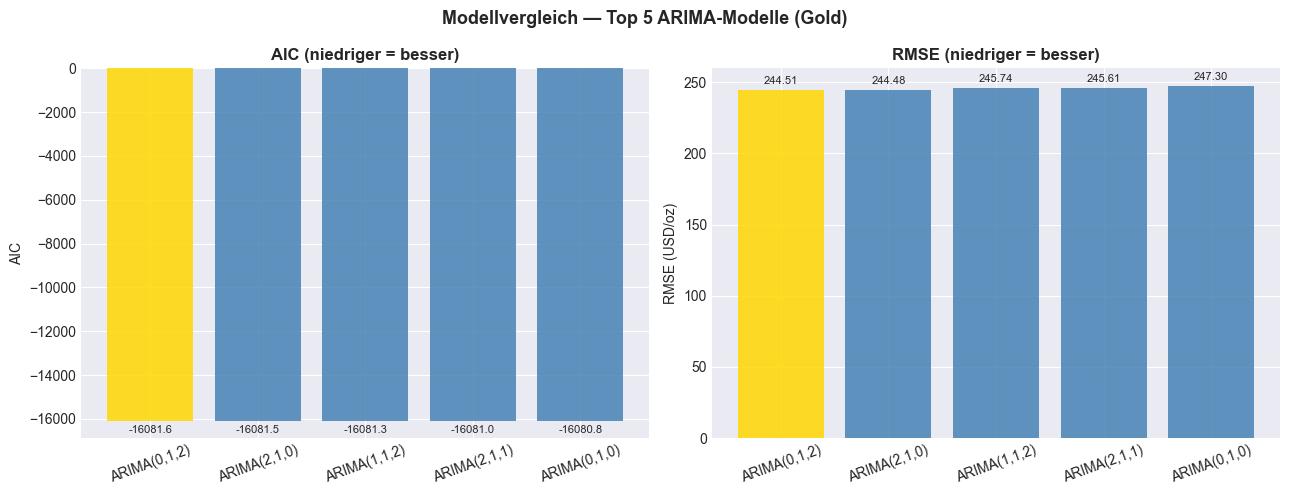


╔══════════════════════════════════════════════════════════════╗
║           ERGEBNISZUSAMMENFASSUNG — Gold (GC=F)             ║
╠══════════════════════════════════════════════════════════════╣
║  Bestes Modell : ARIMA(0,1,2)                               ║
║  AIC           : -16081.56                           ║
║  BIC           : -16064.04                           ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting (60-Tage Out-of-Sample):                       ║
║  MAE   = 211.49 USD/oz                                  ║
║  RMSE  = 244.51 USD/oz                                  ║
║  MAPE  = 4.4205%                                        ║
║  MASE  = 14.9415                                         ║
╚══════════════════════════════════════════════════════════════╝



In [13]:
# Modellvergleich Top 5
top5 = res_df.head(5)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modellvergleich — Top 5 ARIMA-Modelle (Gold)', fontsize=13, fontweight='bold')

colors = [GOLD if i == 0 else 'steelblue' for i in range(len(top5))]
bars = axes[0].bar(top5['Modell'], top5['AIC'], color=colors, edgecolor='none', alpha=0.85)
axes[0].set_title('AIC (niedriger = besser)', fontweight='bold')
axes[0].set_ylabel('AIC')
axes[0].tick_params(axis='x', rotation=20)
axes[0].bar_label(bars, fmt='%.1f', fontsize=8, padding=3)

bars2 = axes[1].bar(top5['Modell'], top5['RMSE'], color=colors, edgecolor='none', alpha=0.85)
axes[1].set_title('RMSE (niedriger = besser)', fontweight='bold')
axes[1].set_ylabel('RMSE (USD/oz)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar_label(bars2, fmt='%.2f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('../reports/gold_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           ERGEBNISZUSAMMENFASSUNG — Gold (GC=F)             ║
╠══════════════════════════════════════════════════════════════╣
║  Bestes Modell : ARIMA({p_best},{d_best},{q_best})                               ║
║  AIC           : {best_model.aic:.2f}                           ║
║  BIC           : {best_model.bic:.2f}                           ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting (60-Tage Out-of-Sample):                       ║
║  MAE   = {mae:.2f} USD/oz                                  ║
║  RMSE  = {rmse:.2f} USD/oz                                  ║
║  MAPE  = {mape:.4f}%                                        ║
║  MASE  = {mase:.4f}                                         ║
╚══════════════════════════════════════════════════════════════╝
""")

In [14]:
# Ergebnisse speichern
result_row = pd.DataFrame([{
    'Asset': 'Gold', 'Ticker': 'GC=F',
    'Modell': f'ARIMA({p_best},{d_best},{q_best})',
    'AIC': round(best_model.aic, 4),
    'BIC': round(best_model.bic, 4),
    'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
    'MAPE (%)': round(mape, 4), 'MASE': round(mase, 4),
}])

results_path = '../reports/results_cv.csv'
os.makedirs('../reports', exist_ok=True)
if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing['Asset'] != 'Gold']
    combined = pd.concat([existing, result_row], ignore_index=True)
else:
    combined = result_row

combined.to_csv(results_path, index=False)
print(f'Ergebnisse gespeichert: {results_path}')
print(combined)

Ergebnisse gespeichert: ../reports/results_cv.csv
  Asset Ticker        Modell         AIC        BIC       MAE      RMSE  \
0  Gold   GC=F  ARIMA(0,1,2) -16081.5578 -16064.044  211.4912  244.5065   

   MAPE (%)     MASE  
0    4.4205  14.9415  
